In [40]:
import yfinance as ynf

In [41]:
ticker= "MSFT"
stock = ynf.Ticker(ticker).history(period="5y")
stock

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-08-05 00:00:00-04:00,275.317856,277.957022,274.569293,277.851440,13900200,0.0,0.0
2021-08-06 00:00:00-04:00,276.882129,277.832219,276.027985,277.793823,16589300,0.0,0.0
2021-08-09 00:00:00-04:00,278.072133,279.799575,276.210319,276.709351,16117600,0.0,0.0
2021-08-10 00:00:00-04:00,277.160439,277.592315,273.705554,274.895569,18616600,0.0,0.0
2021-08-11 00:00:00-04:00,275.634511,277.026083,274.338914,275.385010,13955900,0.0,0.0
...,...,...,...,...,...,...,...
2026-07-29 00:00:00-04:00,393.399994,401.250000,388.739990,390.540009,47209000,0.0,0.0
2026-07-30 00:00:00-04:00,437.899994,458.690002,432.440002,451.100006,110160700,0.0,0.0
2026-07-31 00:00:00-04:00,450.000000,466.839996,449.329987,464.720001,60846000,0.0,0.0


In [42]:
import pandas as pd

In [43]:
stock.isnull().sum()

Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [44]:
stock.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1254 entries, 2021-08-05 00:00:00-04:00 to 2026-08-04 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          1254 non-null   float64
 1   High          1254 non-null   float64
 2   Low           1254 non-null   float64
 3   Close         1254 non-null   float64
 4   Volume        1254 non-null   int64  
 5   Dividends     1254 non-null   float64
 6   Stock Splits  1254 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 78.4 KB


In [45]:
stock.index

DatetimeIndex(['2021-08-05 00:00:00-04:00', '2021-08-06 00:00:00-04:00',
               '2021-08-09 00:00:00-04:00', '2021-08-10 00:00:00-04:00',
               '2021-08-11 00:00:00-04:00', '2021-08-12 00:00:00-04:00',
               '2021-08-13 00:00:00-04:00', '2021-08-16 00:00:00-04:00',
               '2021-08-17 00:00:00-04:00', '2021-08-18 00:00:00-04:00',
               ...
               '2026-07-22 00:00:00-04:00', '2026-07-23 00:00:00-04:00',
               '2026-07-24 00:00:00-04:00', '2026-07-27 00:00:00-04:00',
               '2026-07-28 00:00:00-04:00', '2026-07-29 00:00:00-04:00',
               '2026-07-30 00:00:00-04:00', '2026-07-31 00:00:00-04:00',
               '2026-08-03 00:00:00-04:00', '2026-08-04 00:00:00-04:00'],
              dtype='datetime64[s, America/New_York]', name='Date', length=1254, freq=None)

In [50]:
stock.index = stock.index.tz_localize(None)
stock.index.name = "Date"
stock.to_csv("../data/raw/MSFT.csv", index=True)

In [51]:
df= pd.read_csv("../data/raw/MSFT.csv", index_col="Date", parse_dates=True)
df.shape

(1254, 7)

In [52]:
df.index

DatetimeIndex(['2021-08-05', '2021-08-06', '2021-08-09', '2021-08-10',
               '2021-08-11', '2021-08-12', '2021-08-13', '2021-08-16',
               '2021-08-17', '2021-08-18',
               ...
               '2026-07-22', '2026-07-23', '2026-07-24', '2026-07-27',
               '2026-07-28', '2026-07-29', '2026-07-30', '2026-07-31',
               '2026-08-03', '2026-08-04'],
              dtype='datetime64[us]', name='Date', length=1254, freq=None)

In [53]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1254 entries, 2021-08-05 to 2026-08-04
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          1254 non-null   float64
 1   High          1254 non-null   float64
 2   Low           1254 non-null   float64
 3   Close         1254 non-null   float64
 4   Volume        1254 non-null   int64  
 5   Dividends     1254 non-null   float64
 6   Stock Splits  1254 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 78.4 KB


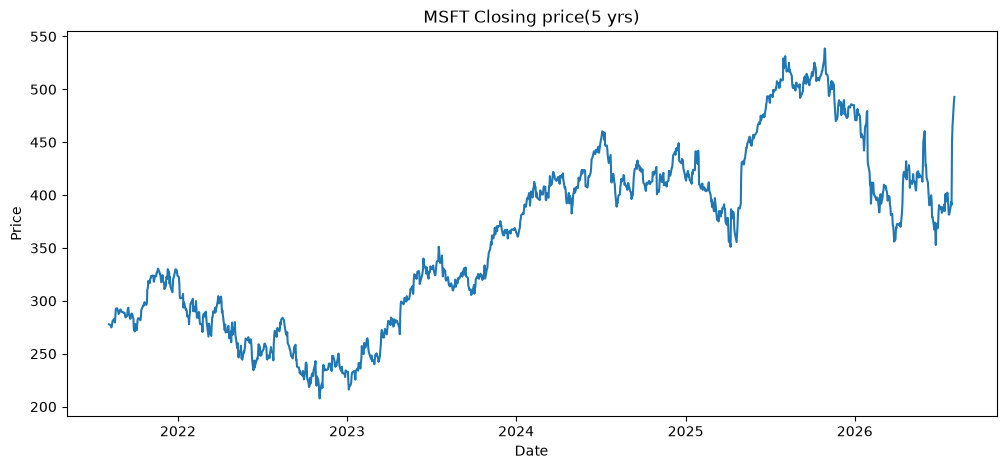

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["Close"])
plt.title("MSFT Closing price(5 yrs)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()